In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

In [29]:
vix_df = yf.download('^VIX',start='1990-01-02',end='2022-02-01', auto_adjust=False, multi_level_index = False)

[*********************100%***********************]  1 of 1 completed


In [30]:
vix_df['MA'] = vix_df.Close.rolling('30D').mean() #calculating the one month moving average of the VIX

In [31]:
vix_df_filt = vix_df[vix_df.Close > 1.5 * vix_df.MA] #buy signal is triggered when VIX rises by more than 50% of its 1 month moving average ie every row should be atleast 1.5 times the moving avg ie if a value is 50% larger than moving avg value

In [32]:
vix_df_filt

,Adj Close,Close,High,Low,Open,Volume,MA
Date,,,,,,,
1990-08-06,35.910000,35.910000,35.910000,35.910000,35.910000,0,20.330476
1990-08-07,32.750000,32.750000,32.750000,32.750000,32.750000,0,20.895000
1994-04-04,23.870001,23.870001,28.299999,23.610001,23.610001,0,15.487000
1997-10-30,38.200001,38.200001,38.560001,35.840000,36.709999,0,23.360909
2001-09-17,41.759998,41.759998,44.330002,39.770000,43.200001,0,25.810625
...,...,...,...,...,...,...,...
2020-03-19,72.000000,72.000000,84.260002,68.570000,80.620003,0,44.842273
2021-01-27,37.209999,37.209999,37.209999,23.709999,23.820000,0,23.929500
2021-11-26,28.620001,28.620001,28.990000,23.879999,26.620001,0,17.673810


In [33]:
pd.Series(vix_df_filt.index).diff() #difference between the above dates in days

0          NaT
1       1 days
2    1336 days
3    1305 days
4    1418 days
        ...   
60      1 days
61    314 days
62    303 days
63      5 days
64     55 days
Name: Date, Length: 65, dtype: timedelta64[ns]

In [34]:
series = pd.Series(vix_df_filt.index).diff() / np.timedelta64(1,'D') >= 30 #filterinbg those rows where we have min distance of one month ie simply checking those values which are at least 30

In [35]:
series[0] = True

In [36]:
signals = vix_df_filt[series.values]

In [37]:
signals.shape #as article suggests, data sow vix signal was triggered 21 times since 1990

(21, 7)

In [43]:
signals

,Adj Close,Close,High,Low,Open,Volume,MA
Date,,,,,,,
1990-08-06,35.910000,35.910000,35.910000,35.910000,35.910000,0,20.330476
1994-04-04,23.870001,23.870001,28.299999,23.610001,23.610001,0,15.487000
1997-10-30,38.200001,38.200001,38.560001,35.840000,36.709999,0,23.360909
2001-09-17,41.759998,41.759998,44.330002,39.770000,43.200001,0,25.810625
2007-02-27,18.309999,18.309999,19.010000,12.100000,12.120000,0,10.921905
2008-09-17,36.220001,36.220001,36.400002,30.250000,31.959999,0,23.478095
2010-05-06,32.799999,32.799999,40.709999,24.430000,25.879999,0,18.951364
2011-08-04,31.660000,31.660000,32.070000,24.309999,24.570000,0,20.732273
2014-10-13,24.639999,24.639999,24.639999,20.520000,21.160000,0,15.625714


In [41]:
sp_df = yf.download('^GSPC',start='1990-01-01',end='2022-02-02')

[*********************100%***********************]  1 of 1 completed


In [42]:
sp_df

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1990-01-02,359.690002,359.690002,351.980011,353.399994,162070000
1990-01-03,358.760010,360.589996,357.890015,359.690002,192330000
1990-01-04,355.670013,358.760010,352.890015,358.760010,177000000
1990-01-05,352.200012,355.670013,351.350006,355.670013,158530000
1990-01-08,353.790009,354.239990,350.540009,352.200012,140110000
...,...,...,...,...,...
2022-01-26,4349.930176,4453.229980,4304.799805,4408.430176,5570640000
2022-01-27,4326.509766,4428.740234,4309.500000,4380.580078,5214200000


In [46]:
from pandas.tseries.offsets import DateOffset

In [49]:
test_ = sp_df[(sp_df.index >= signals.index[0]) &#checking performance of SP, 6 months after those signals occured
    (sp_df.index <= signals.index[0] + DateOffset(months=6))]      

In [51]:
(test_.Close.pct_change() + 1).cumprod()

Ticker,^GSPC
Date,
1990-08-06,NaN
1990-08-07,1.001196
1990-08-08,1.011721
1990-08-09,1.016476
1990-08-10,1.003259
...,...
1991-01-31,1.028407
1991-02-01,1.025775
1991-02-04,1.041593


In [77]:
returns = []

for i in range(len(signals)):
    subdf = sp_df[(sp_df.index >= signals.index[i]) &
              (sp_df.index <= signals.index[i] + DateOffset(months=6))] 
    returns.append((subdf.Close.pct_change() + 1).prod())

In [78]:
pd.Series(returns)[:-2].mean() 

C:\Users\ssk29\AppData\Local\Temp\ipykernel_23560\1765877383.py:1: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  pd.Series(returns)[:-2].mean()


np.float64(1.0787556107406788)

In [86]:
min(r.item() for r in returns) - 1

-0.3271128380040973

In [89]:
returns = [r.iloc[0] for r in returns]
pd.Series(returns) - 1

0     0.070687
1     0.035701
2     0.230247
3     0.122635
4     0.048426
5    -0.327113
6     0.086602
7     0.120685
8     0.116117
9     0.062629
10   -0.026947
11    0.111112
12    0.074374
13    0.072259
14    0.036806
15    0.252754
16    0.172230
17    0.063669
18    0.173482
19   -0.010464
20    0.043634
dtype: float64

<Axes: >

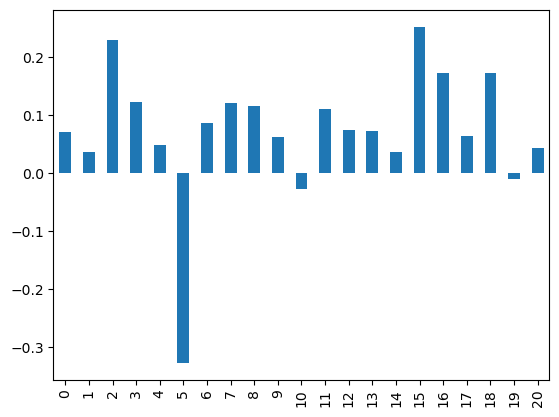

In [90]:
(pd.Series(returns) -1).plot(kind='bar')